# 02 EDA

## 1. Data

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams['figure.dpi'] = 120

ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_selected_cleaned.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

BEHAVIOR_VAR = "EverCigaretteUse"
CONT_VAR = "HowMuchDoYouWeighWithoutShoesInKG"

processed = pd.read_csv(PROCESSED_PATH)
print("Processed data shape:", processed.shape)

Processed data shape: (14041, 3)


In [7]:
#copy
behavior = processed[[BEHAVIOR_VAR, "behavior_binary"]].copy()
behavior_valid = behavior.dropna(subset=["behavior_binary"]).copy()

cont = processed[[CONT_VAR]].copy()
cont_valid = cont.dropna(subset=[CONT_VAR]).copy()

## 2. Behavior Variable EDA

### 2.1 Original code

,raw_code,count,proportion
0,Success (1),7164,0.510
1,Failure (2),6437,0.458
2,Missing or invalid,440,0.031


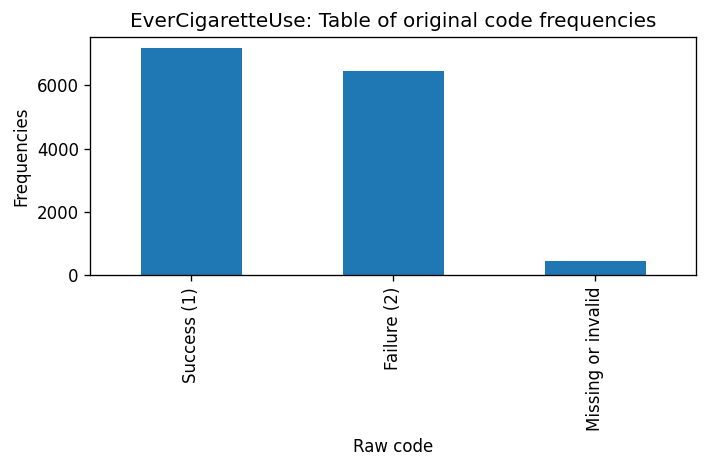

In [8]:
#----------表----------
behavior_raw_freq = (
    behavior[BEHAVIOR_VAR]
    .value_counts(dropna=False)
    .rename_axis("raw_code")
    .reset_index(name="count")
)

behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].astype("object")
behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].where(
    behavior_raw_freq["raw_code"].notna(), "Missing or invalid"
)

# 把原始 code 1, 2 改成更清楚的名稱
behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].replace({
    1: "Success (1)",
    2: "Failure (2)"
})

behavior_raw_freq["proportion"] = (
    behavior_raw_freq["count"] / behavior_raw_freq["count"].sum()
).round(3)

display(behavior_raw_freq)
#----------表----------
#----------圖表----------
raw_plot_counts = (
    behavior[BEHAVIOR_VAR]
    .astype("object")
    .where(behavior[BEHAVIOR_VAR].notna(), "Missing or invalid")
    .value_counts(dropna=False)
    .reindex([1, 2, "Missing or invalid"], fill_value=0)
)
#----------圖表----------
raw_plot_counts.index = ["Success (1)", "Failure (2)", "Missing or invalid"]# 改 x 軸顯示名稱

plt.figure(figsize=(6, 4))
raw_plot_counts.plot(kind="bar")
plt.title("EverCigaretteUse: Table of original code frequencies")
plt.xlabel("Raw code")
plt.ylabel("Frequencies")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_original_bar_chart.png", bbox_inches="tight")
plt.show()

**Observations:** The original responses are concentrated in codes 1 and 2, with only a smaller number of missing values.

### 2.2 Binary recoding

,category,count,proportion
0,Failure (0),6437,0.473274
1,Success (1),7164,0.526726


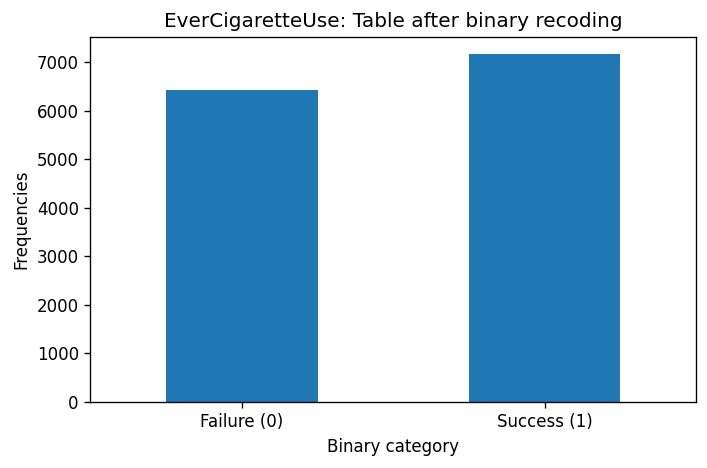

In [9]:
#----------表----------
behavior_binary_summary = pd.DataFrame({
    "category": ["Failure (0)", "Success (1)"],
    "count": [
        int((behavior_valid["behavior_binary"] == 0).sum()),
        int((behavior_valid["behavior_binary"] == 1).sum())
    ]
})
behavior_binary_summary["proportion"] = behavior_binary_summary["count"] / behavior_binary_summary["count"].sum()
behavior_binary_summary.to_csv(TAB_DIR / "02_behavior_binary_summary.csv", index=False)
display(behavior_binary_summary)
#----------圖表----------
binary_plot_counts = behavior_valid["behavior_binary"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
binary_plot_counts.plot(kind="bar")
plt.title("EverCigaretteUse: Table after binary recoding")
plt.xlabel("Binary category")
plt.ylabel("Frequencies")
plt.xticks([0, 1], ["Failure (0)", "Success (1)"], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_binary_bar_chart.png", bbox_inches="tight")
plt.show()

**Observations:** After binary recoding, **Success (1)** accounts for **52.7%** of the valid responses, which is slightly higher than **Failure (0)** at **47.3%**. This suggests that the success category is somewhat more common in the sample and may be above the benchmark proportion of **0.50**.

### 2.3 Additional: EverCigaretteUse success proportion by weight quartile

,weight_quartile,success_proportion,sample_size
0,Q1 (lowest),0.4689,3525
1,Q2,0.4965,2852
2,Q3,0.5569,3135
3,Q4 (highest),0.5963,3171


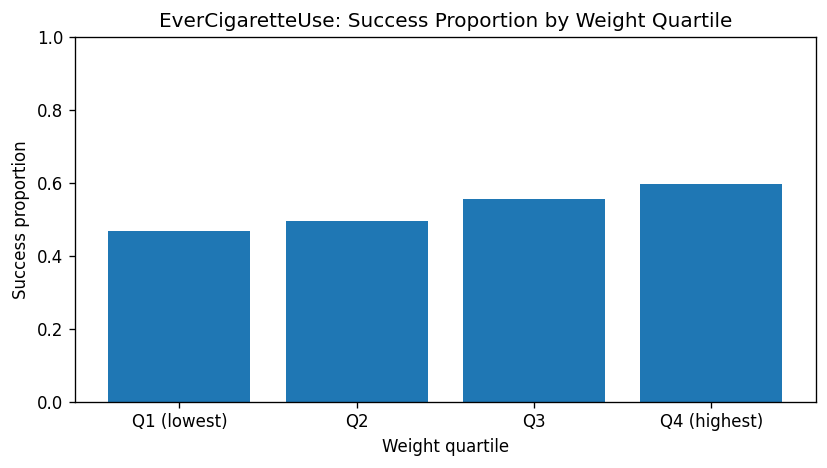

In [10]:
# Additional EDA for behavior variable:
# Success proportion by weight quartile

behavior_weight = processed[["behavior_binary", CONT_VAR]].dropna().copy()

behavior_weight["weight_quartile"] = pd.qcut(
    behavior_weight[CONT_VAR],
    q=4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)

behavior_by_weight_q = (
    behavior_weight.groupby("weight_quartile", observed=False)["behavior_binary"]
    .agg(success_proportion="mean", sample_size="size")
    .reset_index()
)

behavior_by_weight_q["success_proportion"] = behavior_by_weight_q["success_proportion"].round(4)

behavior_by_weight_q.to_csv(TAB_DIR / "02_behavior_by_weight_quartile.csv", index=False)
display(behavior_by_weight_q)

plt.figure(figsize=(7, 4))
plt.bar(
    behavior_by_weight_q["weight_quartile"].astype(str),
    behavior_by_weight_q["success_proportion"]
)
plt.title("EverCigaretteUse: Success Proportion by Weight Quartile")
plt.xlabel("Weight quartile")
plt.ylabel("Success proportion")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_by_weight_quartile.png", bbox_inches="tight")
plt.show()

**Observation:** The success proportion tends to increase across the weight quartiles. In this sample, students in the higher weight quartiles show a higher proportion in the success category than those in the lower quartiles. This suggests that the behavior variable may be related to body weight in a descriptive sense, although this EDA result should not be interpreted as a causal relationship.